Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

Atribuição de Dataframe

In [2]:
df_logs = pd.read_csv('logs_exp_us.csv', sep='\\t', dtype={'EventName': 'category', 'ExpId': 'category'})
df_logs['EventTimestamp'] = pd.to_datetime(df_logs['EventTimestamp'], unit='s')
df_logs = df_logs.rename(columns={'EventName': 'event', 'DeviceIDHash': 'user_id', 'EventTimestamp': 'timestamp', 'ExpId': 'exp_id'})

C:\Users\gamer\AppData\Local\Temp\ipykernel_19692\1516145421.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df_logs = pd.read_csv('logs_exp_us.csv', sep='\\t', dtype={'EventName': 'category', 'ExpId': 'category'})


Pré Análise de Dados

In [3]:
print(df_logs.info())
print(df_logs.describe())
print(df_logs.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   event      244126 non-null  category      
 1   user_id    244126 non-null  int64         
 2   timestamp  244126 non-null  datetime64[ns]
 3   exp_id     244126 non-null  category      
dtypes: category(2), datetime64[ns](1), int64(1)
memory usage: 4.2 MB
None
            user_id                      timestamp
count  2.441260e+05                         244126
mean   4.627568e+18  2019-08-04 10:18:35.842716160
min    6.888747e+15            2019-07-25 04:43:36
25%    2.372212e+18  2019-08-02 14:36:20.249999872
50%    4.623192e+18            2019-08-04 11:49:55
75%    6.932517e+18            2019-08-06 06:55:11
max    9.222603e+18            2019-08-07 21:15:17
std    2.642425e+18                            NaN
                     event              user_id           timestamp 

In [4]:
print(df_logs['exp_id'].unique())
print(df_logs['user_id'].nunique())

['246', '248', '247']
Categories (3, object): ['246', '247', '248']
7551


Adicione uma coluna de data e hora e uma coluna separada para datas

In [5]:
df_logs['hour'] = df_logs['timestamp'].dt.time
df_logs['date'] = df_logs['timestamp'].dt.date
df_logs['date'] = pd.to_datetime(df_logs['date'])
print(df_logs.sample(10))


                     event              user_id           timestamp exp_id  \
96053     MainScreenAppear  7746900626563870083 2019-08-03 14:44:53    248   
175948  OffersScreenAppear   147514000526855717 2019-08-05 21:03:14    248   
9643      MainScreenAppear  3366545372369388717 2019-08-01 08:08:31    247   
197392    CartScreenAppear  3337471580007169353 2019-08-06 14:08:46    246   
141232    MainScreenAppear  3558080488336014649 2019-08-05 01:01:32    247   
31612     MainScreenAppear  6749055260514538416 2019-08-01 17:29:22    248   
108273    MainScreenAppear   558234018943181183 2019-08-04 01:42:26    246   
177248    MainScreenAppear   728850948727363423 2019-08-06 00:42:29    248   
58768     MainScreenAppear  6224840966394928541 2019-08-02 13:37:31    247   
134007    MainScreenAppear  8670981898427866763 2019-08-04 17:08:11    246   

            hour       date  
96053   14:44:53 2019-08-03  
175948  21:03:14 2019-08-05  
9643    08:08:31 2019-08-01  
197392  14:08:46 2019

In [6]:
print(df_logs.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   event      244126 non-null  category      
 1   user_id    244126 non-null  int64         
 2   timestamp  244126 non-null  datetime64[ns]
 3   exp_id     244126 non-null  category      
 4   hour       244126 non-null  object        
 5   date       244126 non-null  datetime64[ns]
dtypes: category(2), datetime64[ns](2), int64(1), object(1)
memory usage: 7.9+ MB
None


Quantos eventos ficam nos registros?

In [7]:
df_logs['event'].unique()

['MainScreenAppear', 'PaymentScreenSuccessful', 'CartScreenAppear', 'OffersScreenAppear', 'Tutorial']
Categories (5, object): ['CartScreenAppear', 'MainScreenAppear', 'OffersScreenAppear', 'PaymentScreenSuccessful', 'Tutorial']

Quantos usuários ficam nos registros?

In [8]:
df_logs['user_id'].nunique()

7551

Qual é o número médio de eventos por usuário?

In [9]:
event_mean_per_user = len(df_logs) / df_logs['user_id'].nunique()
event_mean_per_user

32.33028737915508

Qual é o período de tempo que os dados cobrem? Encontre as datas máxima e mínima. Desenhe um histograma por data e hora. Você pode ter certeza de que possui os dados igualmente completos para todo o período? Os eventos mais antigos podem acabar aparecendo nos diários de alguns usuários por motivos técnicos, e isso pode distorcer o quadro geral. Encontre o momento em que os dados começam a ser completos e ignore a seção anterior. Qual período os dados realmente representam?

In [10]:
print(df_logs['date'].max())
print(df_logs['date'].min())

2019-08-07 00:00:00
2019-07-25 00:00:00


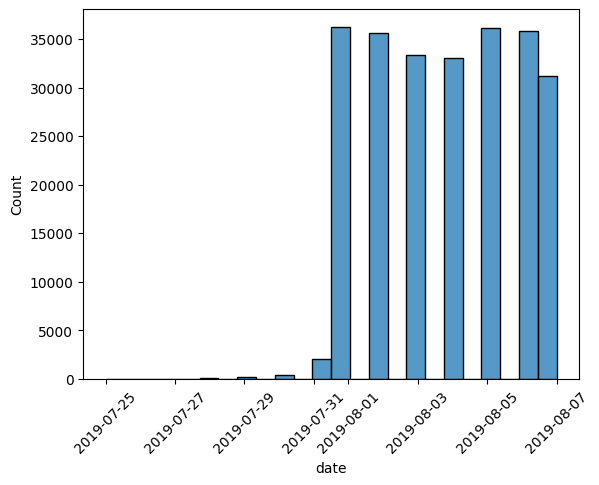

In [11]:
sns.histplot(df_logs['date'], bins=24)
plt.xticks(rotation=45)
plt.show()

Os eventos começam a ser relevantes somente a partir do dia 2019-08-01

In [12]:
df_logs_filter = df_logs[df_logs['date'] > '2019-07-31']
df_logs_filter = df_logs_filter.reset_index(drop=True)
df_logs_filter.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241298 entries, 0 to 241297
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   event      241298 non-null  category      
 1   user_id    241298 non-null  int64         
 2   timestamp  241298 non-null  datetime64[ns]
 3   exp_id     241298 non-null  category      
 4   hour       241298 non-null  object        
 5   date       241298 non-null  datetime64[ns]
dtypes: category(2), datetime64[ns](2), int64(1), object(1)
memory usage: 7.8+ MB


Você perdeu muitos eventos e usuários ao excluir os dados mais antigos?

In [13]:
user_lost = df_logs['user_id'].nunique() - df_logs_filter['user_id'].nunique()
print(f'Foram perdidos {user_lost} usuários.')

event_lost = len(df_logs['event']) - len(df_logs_filter['event'])
print(f'Foram perdidos {event_lost} eventos.')

Foram perdidos 17 usuários.
Foram perdidos 2828 eventos.


Certifique-se de ter usuários de todos os três grupos experimentais.

In [14]:
print(df_logs_filter['exp_id'].unique())
print(df_logs_filter['exp_id'].value_counts())

['246', '247', '248']
Categories (3, object): ['246', '247', '248']
exp_id
248    84726
246    79425
247    77147
Name: count, dtype: int64


Veja quais eventos estão nos diários e sua frequência de ocorrência. Classifique-os por frequência.

In [15]:
print(df_logs_filter['event'].value_counts().sort_values(ascending=False))

event
MainScreenAppear           117431
OffersScreenAppear          46350
CartScreenAppear            42365
PaymentScreenSuccessful     34113
Tutorial                     1039
Name: count, dtype: int64


Encontre o número de usuários que executaram cada uma dessas ações. Ordene os eventos pelo número de usuários. Calcule a proporção de usuários que executaram a ação pelo menos uma vez.

In [ ]:
one_time_event = df_logs_filter.groupby('event')['user_id'].nunique().sort_values(ascending=False).reset_index()

print(one_time_event)


                     event  user_id
0         MainScreenAppear     7419
1       OffersScreenAppear     4593
2         CartScreenAppear     3734
3  PaymentScreenSuccessful     3539
4                 Tutorial      840


C:\Users\gamer\AppData\Local\Temp\ipykernel_19692\3734024538.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  one_time_event = df_logs_filter.groupby('event')['user_id'].nunique().sort_values(ascending=False).reset_index()


In [25]:
one_time_event['proportion'] = (one_time_event['user_id'] / df_logs_filter['user_id'].nunique()) * 100
print(one_time_event)

                     event  user_id  proportion
0         MainScreenAppear     7419   98.473586
1       OffersScreenAppear     4593   60.963632
2         CartScreenAppear     3734   49.561986
3  PaymentScreenSuccessful     3539   46.973719
4                 Tutorial      840   11.149456


Em que ordem você acha que as ações ocorreram? Todos elas fazem parte de uma única sequência? Você não precisa levá-las em consideração ao calcular o funil.

Considerando a proporção constatada de cada evento ele parece começar com MainScreenAppear -> OffersScreenAppear -> CartScreenAppear -> PaymentScreenSuccessful

Porém se considerar os nomes dos eventos nao parece ter sentido, pode haver algum gargalo nesse funil ou o tutorial fica fora do funil, considerando que ele tem somente 11% de cliques de usuários únicos, enquanto o segundo menos ocorrido tem 46% de cliques de usuários unicos